# Pacotes

In [1]:
import pandas as pd

from sklearn import  model_selection
from sklearn.tree import DecisionTreeClassifier
from scipy import stats
from sklearn.model_selection import RandomizedSearchCV 
from sklearn.metrics import confusion_matrix

from sklearn import tree
from matplotlib import pyplot as plt

from sklearn.model_selection import KFold 
from sklearn.model_selection import cross_val_score 

import numpy as np
import seaborn as sns
from prettytable import PrettyTable
import sklearn

# Funções

In [2]:
##############################
###### Matriz de confusão ####
##############################

def matriz_confusao(y_real,y_predito,modelo):

### Grafico ###

  tabela=confusion_matrix(y_real,y_predito)

  group_names = ["True Neg","False Pos","False Neg","True Pos"]
  group_counts = ["{0:0.0f}".format(value) for value in
                tabela.flatten()]
  group_percentages = ["{0:.5%}".format(value) for value in
                     tabela.flatten()/np.sum(tabela)]
  labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in
          zip(group_names,group_counts,group_percentages)]
  labels = np.asarray(labels).reshape(2,2)
  f = plt.figure()
  f.set_figwidth(8)
  f.set_figheight(8)

  sns.heatmap(tabela, annot=labels, fmt="", cmap='Blues')

### Tabela ###
  Resultados=PrettyTable()
  Resultados.field_names=["Métrica","Resultado"]
  Resultados.title= modelo
  Resultados.align["Métrica"]="l"
  Resultados.align["Resultado"]="r"

  Resultados.add_row(["Acurácia:",round(sklearn.metrics.accuracy_score(y_real,y_predito),2)])
  Resultados.add_row(["Precisão:",round(sklearn.metrics.precision_score(y_real,y_predito),2)])
  Resultados.add_row(["Recall:",round(sklearn.metrics.recall_score(y_real,y_predito),2)])
  Resultados.add_row(["F1-Score:",round(sklearn.metrics.f1_score(y_real,y_predito),2)])

  print(Resultados)
  
  return

# Dados

In [3]:
dados = pd.read_csv('C:/Users/debor/Documents/PDPA/Dados/CSV/df_final_und.csv'
                     ,sep = ','
                     ,decimal='.'
                      )

In [4]:
dados.head()

,id_tempo_x,id_tempo_y,id_solicitacao,quinzemin,trintamin,umahora,seishoras,dozehoras,vintequatrohoras,quarentaoitohoras,...,flg_cobertura_vegetal,flg_afloramento_rochoso,flg_favela,flg_ocupacao_desordenada,flg_areas_de_risco,Acoes_DC_0,Acoes_DC_1,Acoes_DC_2,Acoes_DC_3,flg_ocorrencia
0,12434926,NaN,NaN,0.0,0.0,0.0,0.0,0.0,22.4,79.8,...,1,0,0,0,0,0,0,0,0,0.0
1,12157456,12793761.0,1770421.0,1.2,2.6,4.6,10.2,11.8,19.0,111.2,...,0,0,1,0,0,0,0,0,0,0.0
2,11713561,12570666.0,1401120.0,0.0,0.0,0.0,1.0,20.8,92.0,195.2,...,0,0,0,0,1,0,0,1,0,0.0
3,11621311,11670581.0,910319.0,0.0,0.0,0.0,0.4,44.2,52.4,56.6,...,0,0,0,0,0,0,0,0,0,0.0
4,13064461,NaN,NaN,0.0,0.0,0.0,0.0,9.4,13.6,23.6,...,1,0,0,0,0,0,0,0,0,0.0


In [5]:
oot = pd.read_csv('C:/Users/debor/Documents/PDPA/Dados/CSV/df_final_oot.csv'
                     ,sep = ','
                     ,decimal='.'
                      )

# Separação em teste e treinamento

In [6]:
X_treino, X_teste, y_treino, y_teste, idx_treino, idx_teste = model_selection.train_test_split(dados.drop(['flg_ocorrencia'],axis=1), dados['flg_ocorrencia'], dados.index, test_size =1/3,random_state= 42 )
print(X_treino.shape)
print(X_teste.shape)
print(y_treino.shape)
print(y_teste.shape)

(12505, 56)
(6253, 56)
(12505,)
(6253,)


In [15]:
n = len(X_treino.columns)-1

# Árvore de Decisão

In [16]:
classificador_arvore = DecisionTreeClassifier()


lista_parametros = {'criterion': ['gini', 'entropy', 'log_loss'],
    'splitter': ['best', 'random'],
    'max_depth': [i + 1 for i in range(2,30,1)],
    'min_samples_split': [i + 1 for i in range(5,30,1)],
    'min_impurity_decrease': stats.uniform(0, 1)
    }

rand_search = RandomizedSearchCV(classificador_arvore, 
                                 param_distributions = lista_parametros,
                                 cv = 10,
                                 random_state = 42,
                                 scoring = 'f1') 
rand_search.fit(X_treino.iloc[:,3:n], y_treino) 

RandomizedSearchCV(cv=10, estimator=DecisionTreeClassifier(),
                   param_distributions={'criterion': ['gini', 'entropy',
                                                      'log_loss'],
                                        'max_depth': [3, 4, 5, 6, 7, 8, 9, 10,
                                                      11, 12, 13, 14, 15, 16,
                                                      17, 18, 19, 20, 21, 22,
                                                      23, 24, 25, 26, 27, 28,
                                                      29, 30],
                                        'min_impurity_decrease': <scipy.stats._distn_infrastructure.rv_frozen object at 0x000001A3437DEF10>,
                                        'min_samples_split': [6, 7, 8, 9, 10,
                                                              11, 12, 13, 14,
                                                              15, 16, 17, 18,
                                                              19, 20, 21, 22,
                                                              23, 24, 25, 26,
                                                              27, 28, 29, 30],
                                        'splitter': ['best', 'random']},
                   random_state=42, scoring='f1')

In [17]:
rand_search.best_estimator_

DecisionTreeClassifier(criterion='entropy', max_depth=8,
                       min_impurity_decrease=0.0007787658410143283,
                       min_samples_split=26)

In [18]:
classificador_arvore = DecisionTreeClassifier(max_depth=8, min_impurity_decrease=0.0007787658410143283,
                       min_samples_split=26)
classificador_arvore.fit(X_treino.iloc[:,3:n], y_treino) 

DecisionTreeClassifier(max_depth=8, min_impurity_decrease=0.0007787658410143283,
                       min_samples_split=26)

In [22]:
text_representation = tree.export_text(classificador_arvore, feature_names = list(X_treino.iloc[:,3:n].columns) )
print(text_representation)

fig = plt.figure(figsize=(250,200))
_ = tree.plot_tree(classificador_arvore, 
                   feature_names=X_treino.iloc[:,3:n].columns,
                   filled=True)

|--- flg_comunidades <= 0.50
|   |--- setentaduashoras <= 95.90
|   |   |--- flg_areas_de_risco <= 0.50
|   |   |   |--- noventaseishoras <= 57.20
|   |   |   |   |--- class: 0.0
|   |   |   |--- noventaseishoras >  57.20
|   |   |   |   |--- Curv_Vertical_numerica <= -0.02
|   |   |   |   |   |--- Curv_Horizontal_numerica <= 0.58
|   |   |   |   |   |   |--- ADD_divisores_talvegues <= 8.02
|   |   |   |   |   |   |   |--- ADD_divisores_talvegues <= 7.05
|   |   |   |   |   |   |   |   |--- class: 0.0
|   |   |   |   |   |   |   |--- ADD_divisores_talvegues >  7.05
|   |   |   |   |   |   |   |   |--- class: 1.0
|   |   |   |   |   |   |--- ADD_divisores_talvegues >  8.02
|   |   |   |   |   |   |   |--- class: 0.0
|   |   |   |   |   |--- Curv_Horizontal_numerica >  0.58
|   |   |   |   |   |   |--- Orientacao_octantes <= 6.40
|   |   |   |   |   |   |   |--- class: 1.0
|   |   |   |   |   |   |--- Orientacao_octantes >  6.40
|   |   |   |   |   |   |   |--- class: 0.0
|   |   |   |  

# Floresta de decisão

In [27]:
from sklearn.ensemble import RandomForestClassifier

In [28]:
classificador_floresta = RandomForestClassifier()


lista_parametros = {'criterion': ['gini', 'entropy', 'log_loss'],
    'max_depth': [i + 1 for i in range(2,30,1)],
    'min_samples_split': [i + 1 for i in range(5,30,1)],
    'min_impurity_decrease': stats.uniform(0, 1),
    'random_state': [42]
    }

rand_search = RandomizedSearchCV(classificador_floresta, 
                                 param_distributions = lista_parametros,
                                 cv = 10,
                                 random_state = 42,
                                 scoring = 'f1') 
rand_search.fit(X_treino.iloc[:,3:n], y_treino) 

RandomizedSearchCV(cv=10, estimator=RandomForestClassifier(),
                   param_distributions={'criterion': ['gini', 'entropy',
                                                      'log_loss'],
                                        'max_depth': [3, 4, 5, 6, 7, 8, 9, 10,
                                                      11, 12, 13, 14, 15, 16,
                                                      17, 18, 19, 20, 21, 22,
                                                      23, 24, 25, 26, 27, 28,
                                                      29, 30],
                                        'min_impurity_decrease': <scipy.stats._distn_infrastructure.rv_frozen object at 0x000001A348F7C160>,
                                        'min_samples_split': [6, 7, 8, 9, 10,
                                                              11, 12, 13, 14,
                                                              15, 16, 17, 18,
                                                              19, 20, 21, 22,
                                                              23, 24, 25, 26,
                                                              27, 28, 29, 30],
                                        'random_state': [42]},
                   random_state=42, scoring='f1')

In [29]:
rand_search.best_estimator_

RandomForestClassifier(criterion='entropy', max_depth=8,
                       min_impurity_decrease=0.0007787658410143283,
                       min_samples_split=26, random_state=42)

In [30]:
classificador_floresta = RandomForestClassifier(criterion='entropy', max_depth=8,
                       min_impurity_decrease=0.0007787658410143283,
                       min_samples_split=26, random_state=42)
classificador_floresta.fit(X_treino.iloc[:,3:n], y_treino) 

RandomForestClassifier(criterion='entropy', max_depth=8,
                       min_impurity_decrease=0.0007787658410143283,
                       min_samples_split=26, random_state=42)

# Qualidade do modelo

## Validação Cruzada

In [23]:
kfold  = KFold(n_splits=10, shuffle=False)
result_arvore = cross_val_score(classificador_arvore, X_treino.iloc[:,3:n], y_treino, cv = kfold)
print('Árvore de decisão')
print('Média da acurácia:', np.mean(result_arvore), 'Variância da acurácia', np.std(result_arvore))

Árvore de decisão
Média da acurácia: 0.8287865067945643 Variância da acurácia 0.01049946818804651


In [35]:
kfold  = KFold(n_splits=10, shuffle=False)
result_floresta = cross_val_score(classificador_floresta, X_treino.iloc[:,3:n], y_treino, cv = kfold)
print('Floresta de decisão')
print('Média da acurácia:', np.mean(result_floresta), 'Variância da acurácia', np.std(result_floresta))

Floresta de decisão
Média da acurácia: 0.8735682174260591 Variância da acurácia 0.012556515622693632


## Teste - OOS

+-----------------------+
|   Árvore de decisão   |
+-----------+-----------+
| Métrica   | Resultado |
+-----------+-----------+
| Acurácia: |      0.86 |
| Precisão: |      0.82 |
| Recall:   |      0.93 |
| F1-Score: |      0.87 |
+-----------+-----------+


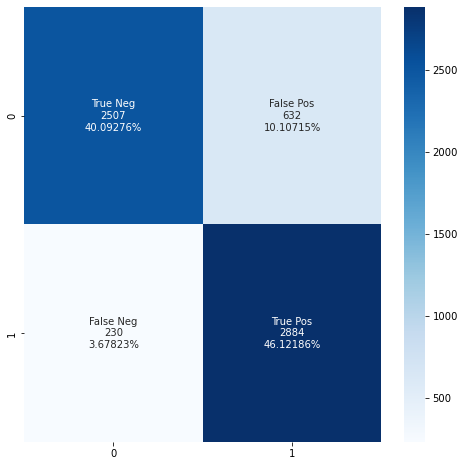

In [25]:
matriz_confusao(y_teste, classificador_arvore.predict(X_teste.iloc[:,3:n]),"Árvore de decisão")

+-----------------------+
|  Floresta de decisão  |
+-----------+-----------+
| Métrica   | Resultado |
+-----------+-----------+
| Acurácia: |      0.87 |
| Precisão: |      0.85 |
| Recall:   |       0.9 |
| F1-Score: |      0.88 |
+-----------+-----------+


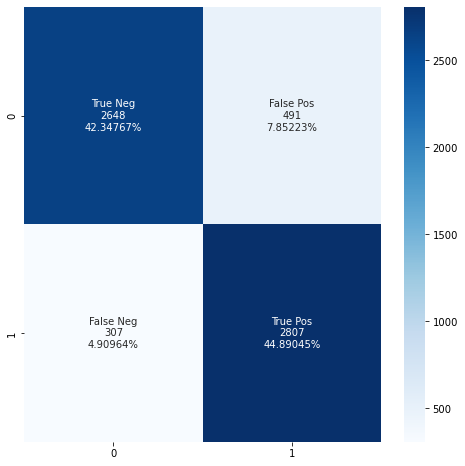

In [37]:
matriz_confusao(y_teste, classificador_floresta.predict(X_teste.iloc[:,3:n]),"Floresta de decisão")

## Teste OOT

+-----------------------+
|   Árvore de decisão   |
+-----------+-----------+
| Métrica   | Resultado |
+-----------+-----------+
| Acurácia: |      0.96 |
| Precisão: |      0.61 |
| Recall:   |      0.45 |
| F1-Score: |      0.52 |
+-----------+-----------+


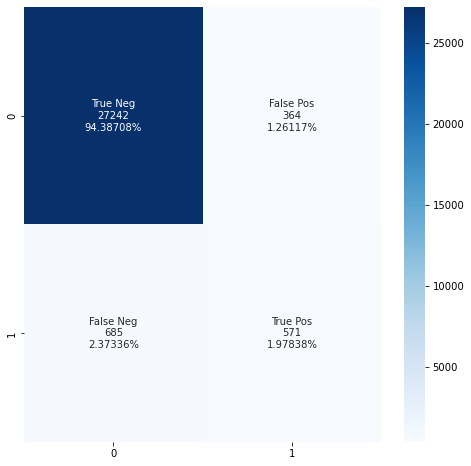

In [26]:
matriz_confusao(oot.iloc[:,43], classificador_arvore.predict(oot.iloc[:,3:n]),"Árvore de decisão")

+-----------------------+
|  Floresta de decisão  |
+-----------+-----------+
| Métrica   | Resultado |
+-----------+-----------+
| Acurácia: |      0.96 |
| Precisão: |      0.97 |
| Recall:   |      0.08 |
| F1-Score: |      0.14 |
+-----------+-----------+


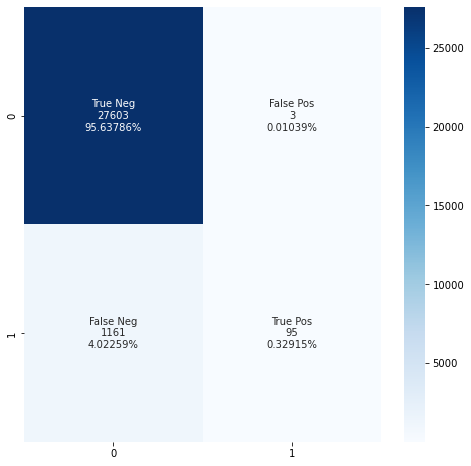

In [39]:
matriz_confusao(oot.iloc[:,43], classificador_floresta.predict(oot.iloc[:,3:n]),"Floresta de decisão")